### Step1: Setup and import

In [1]:
# %%
import subprocess
import sys

#install packages
packages = ['mediapipe','opencv-python','numpy','scikit-learn']

for package in packages:
    subprocess.check_call([sys.executable, "-m","pip","install",package, "-q"])
print("ALl packages installed successfully")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


ALl packages installed successfully



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks import python
import numpy as np
import math
import time
import os
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display
print("ALl library imported successfully")
print(f"MediaPipe version {mp.__version__}")
print(f"CV2 version {cv2.__version__}")

/Users/pembagelusherpa/.pyenv/versions/3.11.5/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


ALl library imported successfully
MediaPipe version 0.10.35
CV2 version 4.13.0


### Step 2: Download mediapipe models

In [3]:
MODEL_DIR = os.path.expanduser("~/mediapipe")
os.makedirs(MODEL_DIR, exist_ok= True)
# URLs for the models
HAND_LANDMARKER_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
GESTURE_RECOGNIZER_URL = "https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/latest/gesture_recognizer.task"

#define path to save model
HAND_LANDMARKER_PATH= os.path.join(MODEL_DIR, "hand_landmarker.task")
GESTURE_RECOGNIZER_PATH= os.path.join(MODEL_DIR, "gesture_recognizer.task")

print("Model path defined")
print(f"Model dir: {MODEL_DIR}")

Model path defined
Model dir: /Users/pembagelusherpa/mediapipe


In [4]:
## functions to download model

import os
import urllib.request

def download_model(model_url, model_path, model_name):

    # check if file exists
    if os.path.exists(model_path):
        print(f"{model_name} already exists at {model_path}")
        return model_path

    print(f"Downloading {model_name}...")

    try:
        def progress_hook(block_num, block_size, total_size):
            downloaded = block_num * block_size
            percent = min(int(downloaded * 100 / total_size), 100)
            print(f"\rProgress: {percent}%", end="")

        urllib.request.urlretrieve(
            model_url,
            model_path,
            progress_hook
        )

        print("\nDownload completed successfully!")

        return model_path

    except Exception as e:
        print("Error:", e)
        return None
print("Function created successfully")

Function created successfully


In [5]:
## download model
print("Downloading models.....")
hand_model_path = download_model(
    HAND_LANDMARKER_URL,
    HAND_LANDMARKER_PATH,
    "Hand landmarker Model"
)
print(hand_model_path)
gesture_model_path = download_model(
    GESTURE_RECOGNIZER_URL,
    GESTURE_RECOGNIZER_PATH,
    "Gesture landmarker Model"
)

if hand_model_path and gesture_model_path:
    print("Model is ready to go....")
else:
    print("Failed to download")


Hand landmarker Model already exists at /Users/pembagelusherpa/mediapipe/hand_landmarker.task
/Users/pembagelusherpa/mediapipe/hand_landmarker.task
Gesture landmarker Model already exists at /Users/pembagelusherpa/mediapipe/gesture_recognizer.task
Model is ready to go....


### Step 3: INITIALIZE PIPLELINE

In [6]:
hand_options = vision.HandLandmarkerOptions(
    base_options= python.BaseOptions(
        model_asset_path = hand_model_path
    ),
    num_hands=2,
    min_hand_detection_confidence=0.7,
    min_hand_presence_confidence=0.5,
    
)

hand_landmarker = vision.HandLandmarker.create_from_options(hand_options)
print("Hand landmarker initialized successfully")


I0000 00:00:1782050466.354483 2249030 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
I0000 00:00:1782050466.532550 2249030 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782050466.553941 2249033 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Hand landmarker initialized successfully


W0000 00:00:1782050466.576875 2249033 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [7]:
# create a gesture recognizer

gesture_options = vision.GestureRecognizerOptions(
    base_options= python.BaseOptions(
        model_asset_path = gesture_model_path
    ),
    num_hands=2,
    min_hand_detection_confidence=0.7,
    min_hand_presence_confidence=0.5,
    
)

gesture_recognizer = vision.GestureRecognizer.create_from_options(gesture_options)
print("Gesture recognizer initialized successfully")

Gesture recognizer initialized successfully


I0000 00:00:1782050466.593111 2249047 hand_gesture_recognizer_graph.cc:257] Custom gesture classifier is not defined.
I0000 00:00:1782050466.602809 2249047 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1782050466.615011 2249050 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782050466.636061 2249055 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782050466.638063 2249055 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782050466.638149 2249055 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Undestanding hand landmarks

In [8]:
# 21 points in one hand
landmark_info = {
    0: "Wrist (Center of hand)",
    4: "Thumb - TIP",
    8: "Index - TIP",
    12: "Middle - TIP",
    16: "Ring - TIP",
    20: "Pinky - TIP"
}
print("Import landmark")
for idx , name in landmark_info.items():
    print(f"Landmark {idx:2d}:{name}")

Import landmark
Landmark  0:Wrist (Center of hand)
Landmark  4:Thumb - TIP
Landmark  8:Index - TIP
Landmark 12:Middle - TIP
Landmark 16:Ring - TIP
Landmark 20:Pinky - TIP


✓ Test image created: (400, 500, 3)
  Size: 500×400 pixels
  Saved as: test_hand_image.jpg


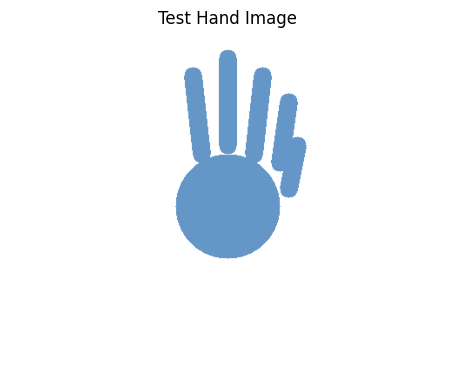

In [9]:
#create test image for hand
# STEP 5.1: Create a sample image
# In real usage, you'd load an actual hand photo

# Create a blank image (white background)
test_image = np.ones((400, 500, 3), dtype=np.uint8) * 255

# Draw a simple hand shape (for demonstration)
# Palm - circle in center
cv2.circle(test_image, (250, 200), 60, (200, 150, 100), -1)

# Fingers - lines from palm
cv2.line(test_image, (220, 140), (210, 50), (200, 150, 100), 20)   # Thumb
cv2.line(test_image, (250, 130), (250, 30), (200, 150, 100), 20)   # Index
cv2.line(test_image, (280, 140), (290, 50), (200, 150, 100), 20)   # Middle
cv2.line(test_image, (310, 150), (320, 80), (200, 150, 100), 20)   # Ring
cv2.line(test_image, (320, 180), (330, 130), (200, 150, 100), 20)  # Pinky

# Save and display
test_image_path = "test_hand_image.jpg"
cv2.imwrite(test_image_path, test_image)

print(f"✓ Test image created: {test_image.shape}")
print(f"  Size: 500×400 pixels")
print(f"  Saved as: {test_image_path}")

# Display
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title("Test Hand Image")
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
## import real hand image and identify landmark
hand= cv2.imread("hand_one.jpg")

## now convert BGR to RGB
rgb_img = cv2.cvtColor(hand, cv2.COLOR_RGB2BGR)

##Create media pipleline object
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data = rgb_img)

## detect landmark 
hand_detection = hand_landmarker.detect(mp_img)
print("Detection successful")


Detection successful


W0000 00:00:1782050466.940180 2249039 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [11]:
## analyze detected landmarks

if len(hand_detection.hand_landmarks) > 0:
    landmarks = hand_detection.hand_landmarks[0]

    print(f"Landmark Coordinates (First hand)")
    print(f"{'Index':<6} | {'landmark':<20} | {'X':<8} | {'Y':<8} | {'Z':<8}")

    print("-" * 65)

    # show key landmarks
    key_indices = {0,4,8,12,16,20}
    key_name = ["Wrist", "Thumb", "Index", "Middle", "Ring", "Pinky"]

    for idx, name in zip(key_indices, key_name):
        lm = landmarks[idx]
        print(f"{idx:<6} | { name:<20} | {lm.x:<8.4f} | {lm.y:<8.4f} | {lm.z:<8.4f}")

Landmark Coordinates (First hand)
Index  | landmark             | X        | Y        | Z       
-----------------------------------------------------------------
0      | Wrist                | 0.5958   | 0.8390   | 0.0000  
16     | Thumb                | 0.6940   | 0.1347   | -0.2013 
4      | Index                | 0.1127   | 0.5042   | -0.2122 
20     | Middle               | 0.8767   | 0.2678   | -0.1940 
8      | Ring                 | 0.4107   | 0.1246   | -0.1894 
12     | Pinky                | 0.5677   | 0.0860   | -0.1867 


In [12]:
## extract features from landmarks 

def extract_landmark_features(landmarks):
    features = np.zeros(63)

    for i in range(len(landmarks)):
        features[i*3] = landmarks[i].x
        features[i*3+1] = landmarks[i].y
        features[i*3+2] = landmarks[i].z
    
    return features

if len(hand_detection.hand_landmarks) > 0:
    landmarks = hand_detection.hand_landmarks[0]
    features = extract_landmark_features(landmarks)

In [13]:
## draw hand skeleton 
def draw_hand_skeleton(frame, hand_landmarks, w, h):
    ## connection
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),      # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),      # Index
        (5, 9), (9,10), (10,11), (11,12),    # Middle
        (9,13), (13,14), (14,15), (15,16),   # Ring
        (13,17), (17,18), (18,19), (19,20),  # Pinky
        (0,17)                               # Palm
    ]

    # draw a line between connection
    for hand_landmarks in hand_detection.hand_landmarks:
        for start_idx, end_idx in connections:
            start = hand_landmarks[start_idx]
            end = hand_landmarks[end_idx]

            start_pos = (int(start.x * w), int(start.y * h))
            end_pos = (int(end.x * w), int(end.y * h))

            cv2.line(hand, start_pos, end_pos, (0, 255, 0), 2)

                #Draw landmark circles
    
        cv2.circle(hand, start_pos, 5, (0, 0, 255), -1)
        cv2.circle(hand, end_pos, 5, (0,0,255), -1)
        return frame

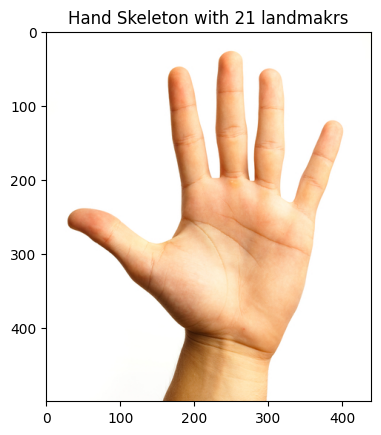

In [14]:
annoted_img = hand.copy()
h,w = annoted_img.shape[:2]
if(len(hand_detection.hand_landmarks))>0:
    landmarks = hand_detection.hand_landmarks[0]
    annoted_img = draw_hand_skeleton(annoted_img, landmarks, w,h)

    cv2.imwrite("hand_sekeleton.jpg",annoted_img)

    plt.imshow(cv2.cvtColor(annoted_img, cv2.COLOR_RGB2BGR))
    plt.title("Hand Skeleton with 21 landmakrs")
    plt.show()

    

In [15]:
# Define connections (which points connect)
def draw_hand_skeleton(frame, hand_landmarks, w, h):
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),          # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),          # Index
        (0, 9), (9, 10), (10, 11), (11, 12),     # Middle
        (0, 13), (13, 14), (14, 15), (15, 16),   # Ring
        (0, 17), (17, 18), (18, 19), (19, 20),   # Pinky
        (5, 9), (9, 13), (13, 17)                # Palm
    ]
    
    # Draw lines (connections)
    for start_idx, end_idx in connections:
        start = hand_landmarks[start_idx]
        end = hand_landmarks[end_idx]
        
        # Convert normalized coords to pixel coords
        start_pos = (int(start.x * w), int(start.y * h))
        end_pos = (int(end.x * w), int(end.y * h))
        
        cv2.line(frame, start_pos, end_pos, (0, 255, 0), 2)
    
    # Draw landmarks (circles)
    for i, landmark in enumerate(hand_landmarks):
        x = int(landmark.x * w)
        y = int(landmark.y * h)
        
        # Different colors for different point types
        if i == 0:  # Wrist
            color = (255, 0, 0)  # Blue
            radius = 8
        elif i in [4, 8, 12, 16, 20]:  # Fingertips
            color = (0, 255, 0)  # Green
            radius = 6
        else:  # Joints
            color = (0, 0, 0)  # Light gray
            radius = 4
        
        cv2.circle(frame, (x, y), radius, color, -1)
    
    return frame

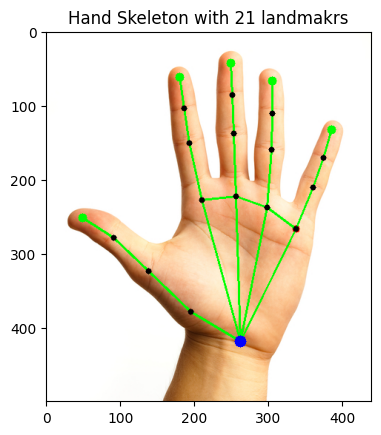

In [16]:
annoted_img = hand.copy()
h,w = annoted_img.shape[:2]
if(len(hand_detection.hand_landmarks))>0:
    landmarks = hand_detection.hand_landmarks[0]
    annoted_img = draw_hand_skeleton(annoted_img, landmarks, w,h)

    cv2.imwrite("hand_sekeleton.jpg",annoted_img)

    plt.imshow(cv2.cvtColor(annoted_img, cv2.COLOR_RGB2BGR))
    plt.title("Hand Skeleton with 21 landmakrs")
    plt.show()

    

### Create webcam project

Web cam -> Capture frame -> Image flip -> Convert RGB -> MediaPiple hand detection -> hand landmarks -> gesture recognization -> Quit

In [ ]:
import cv2
import mediapipe as mp
import time


def run_gesture_recognization_webcam():

    print("Initializing webcam...")

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Could not open webcam")
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    cap.set(cv2.CAP_PROP_FPS, 30)

    print("Webcam initialized")
    print("Press 'q' to quit")

    time.sleep(2)

    frame_count = 0
    previous_time = time.time()
    fps = 0

    try:

        while True:

            ret, frame = cap.read()

            if not ret:
                print("Failed to read frame")
                break

            # mirror image
            frame = cv2.flip(frame, 1)

            h, w = frame.shape[:2]

            # Convert BGR -> RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=rgb_frame
            )

            hand_result = hand_landmarker.detect(mp_image)
            gesture_result = gesture_recognizer.recognize(mp_image)

            gesture_text = "No Hand Detected"
            hand_count = 0

            if hand_result.hand_landmarks:

                hand_count = len(hand_result.hand_landmarks)

                for idx, hand_landmarks in enumerate(
                    hand_result.hand_landmarks
                ):

                    # Draw skeleton
                    frame = draw_hand_skeleton(
                        frame,
                        hand_landmarks,
                        w,
                        h
                    )

                    # Get gesture
                    if (
                        gesture_result.gestures
                        and idx < len(gesture_result.gestures)
                    ):

                        gesture_hand = gesture_result.gestures[idx]

                        if gesture_hand:

                            top_gesture = gesture_hand[0]

                            gesture_text = (
                                f"{top_gesture.category_name} "
                                f"{top_gesture.score:.0%}"
                            )

            # FPS calculation
            frame_count += 1

            current_time = time.time()

            if current_time - previous_time >= 1:

                fps = frame_count

                frame_count = 0

                previous_time = current_time

            # Top banner
            cv2.rectangle(
                frame,
                (0, 0),
                (w, 100),
                (30, 30, 30),
                -1
            )

            # Gesture text
            cv2.putText(
                frame,
                f"Gesture: {gesture_text}",
                (15, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 120),
                2
            )

            # Hand count
            cv2.putText(
                frame,
                f"Hands: {hand_count}",
                (15, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            # FPS
            cv2.putText(
                frame,
                f"FPS: {fps}",
                (500, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2
            )

            cv2.imshow(
                "Live Gesture Recognition",
                frame
            )

            key = cv2.waitKey(1) & 0xFF

            if key == ord("q"):
                print("Quitting...")
                break

    except Exception as e:
        print(f"Error: {e}")

    finally:

        cap.release()
        cv2.destroyAllWindows()

        print("Webcam closed")


run_gesture_recognization_webcam()

Initializing webcam...
Webcam initialized
Press 'q' to quit
Quitting...
Webcam closed


: 